# Neural Network Forecast-Error Correction for ECB SPF Forecasts

This notebook adapts the existing PyTorch MLP training structure to the final
SPF modelling dataset.

The target is:

```text
forecast_error = actual_value - rolling_1y_forecast
```

The neural network predicts `forecast_error`. The corrected forecast is:

```text
corrected_forecast = rolling_1y_forecast + predicted_error
```

The core training structure is kept intentionally close to the previous
notebook: feed-forward neural networks, validation-based hyperparameter
selection, early stopping, and optional seed ensembles.

## A100 performance notes

This dataset is much smaller than the original stock-market panel, so the
training bottleneck is not data transfer. The notebook still keeps the same
efficient PyTorch style:

- no `DataLoader`
- tensors are moved to the selected device before each refit
- mini-batches are created by shuffling tensor indices on-device
- CUDA uses TF32 matmul when available

One important change is that features are no longer converted directly from
the raw DataFrame to tensors. The final SPF dataset has missing values in
some predictors, so each train/validation/test split is first imputed and
scaled using the training sample only. After that preprocessing step, the
clean numeric matrices are converted to PyTorch tensors.

---
## Step 0: Install Dependencies & Imports

In [1]:
from pathlib import Path
from copy import deepcopy
import warnings
import time
import gc

import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

warnings.filterwarnings("ignore")

DEVICE_PREFERENCE = "auto"  # one of: auto, cpu, cuda, mps
HAS_CUDA = torch.cuda.is_available()
HAS_MPS = hasattr(torch.backends, "mps") and torch.backends.mps.is_built()
MPS_AVAILABLE = HAS_MPS and torch.backends.mps.is_available()


def resolve_device(preference: str) -> torch.device:
    """Resolve the execution device from a simple notebook config flag."""
    preference = preference.lower()

    if preference == "auto":
        if HAS_CUDA:
            return torch.device("cuda")
        if MPS_AVAILABLE:
            return torch.device("mps")
        return torch.device("cpu")

    if preference == "cuda":
        if not HAS_CUDA:
            raise RuntimeError("CUDA requested but is not available.")
        return torch.device("cuda")

    if preference == "mps":
        if not MPS_AVAILABLE:
            raise RuntimeError("MPS requested but is not available.")
        return torch.device("mps")

    if preference == "cpu":
        return torch.device("cpu")

    raise ValueError(f"Unknown DEVICE_PREFERENCE={preference!r}")


DEVICE = resolve_device(DEVICE_PREFERENCE)

# ====================================================
# A100 optimization: small global switches that improve speed on
# CUDA and harmless elsewhere.
#   - cudnn.benchmark picks the fastest conv/linear kernel
#     for fixed shapes (the shapes never change here).
#   - TF32 matmul is ~2-3x faster than strict FP32 on
#     Ampere+ with a precision loss well below anything
#     that matters for monthly return forecasts.
# ====================================================
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")
print(f"Device preference: {DEVICE_PREFERENCE}")
print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {MPS_AVAILABLE}")
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"CUDA device: {props.name} ({props.total_memory / 1024**3:.1f} GB)")

DATA_DIR = Path("data")

# ====================================================
# SMOKE TEST MODE
# Set to True for a quicker validation run. Smoke mode keeps
# the real LR/L1 grid and training settings, but limits the
# run to NN2 and the first few annual refits.
# Set to False for the full replication.
# ====================================================
SMOKE_TEST = False
SMOKE_SPLITS = 5

if SMOKE_TEST:
    print("\n** SMOKE TEST MODE — reduced settings for quick validation **")


Using device: cuda
Device preference: auto
PyTorch version: 2.10.0+cu128
MPS available: False
CUDA device: NVIDIA A100-SXM4-40GB (39.5 GB)


---
## Step 1: Load the Final SPF Modelling Dataset

The notebook now expects the macro-matched final dataset created by
`step3_final_dataset.ipynb`.

Preferred Colab path:

```text
/content/drive/MyDrive/SPF_NN_Final_Assignment/final_model_dataset.csv
```

As a fallback, it also checks the CSV uploaded through Drive as
`final_model_dataset_macro_matched.csv`. If the notebook is run locally, it
uses `Data/final_model_dataset.csv`.

In [2]:
from pathlib import Path
import pandas as pd
import shutil

# New macro-matched dataset uploaded after dropping rows without EA-MD-QD values.
DRIVE_FILE_ID = "13h4aqxBLSoNBSGV6jFA8vNd5c-fbsgVn"
DRIVE_FILE_NAME = "final_model_dataset_macro_matched.csv"
DRIVE_PROJECT_FOLDER = "SPF_NN_Final_Assignment"

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/data")
    my_drive = Path("/content/drive/MyDrive")
    drive_candidates = [
        my_drive / DRIVE_PROJECT_FOLDER / "final_model_dataset.csv",
        my_drive / DRIVE_FILE_NAME,
    ]
    DRIVE_FILE = next((path for path in drive_candidates if path.exists()), None)
else:
    DATA_DIR = Path("Data")
    DRIVE_FILE = DATA_DIR / "final_model_dataset.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_FILE = DATA_DIR / "final_model_dataset.csv"

if DRIVE_FILE is None or not DRIVE_FILE.exists():
    if IN_COLAB:
        checked = "\n".join(f"  - {path}" for path in drive_candidates)
        raise FileNotFoundError(
            "Could not find the macro-matched dataset in Google Drive. "
            f"Checked:\n{checked}"
        )
    raise FileNotFoundError(f"Could not find the local dataset at {DRIVE_FILE}.")

# Copy to the runtime/local data folder so training does not read repeatedly
# from Google Drive.
if not LOCAL_FILE.exists() or LOCAL_FILE.stat().st_size != DRIVE_FILE.stat().st_size:
    print("Copying final dataset to runtime data folder...")
    shutil.copy2(DRIVE_FILE, LOCAL_FILE)
    print("Copy complete.")
else:
    print("Local runtime copy already exists. Skipping copy.")

panel = pd.read_csv(LOCAL_FILE)

required_cols = [
    "survey_round",
    "survey_year",
    "survey_quarter",
    "variable",
    "fct_source",
    "rolling_1y_forecast",
    "actual_value",
    "forecast_error",
]
missing_required = [col for col in required_cols if col not in panel.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

panel = panel.sort_values(
    ["survey_year", "survey_quarter", "variable", "fct_source"]
).reset_index(drop=True)

panel_memory_mb = panel.memory_usage(deep=True).sum() / 1024**2

print(f"Dataset source: {DRIVE_FILE}")
print(f"Panel shape: {panel.shape}")
print(f"Survey rounds: {panel['survey_round'].min()} to {panel['survey_round'].max()}")
print(f"Variables: {sorted(panel['variable'].unique())}")
print(f"Memory usage: {panel_memory_mb:.1f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Local runtime copy already exists. Skipping copy.
Dataset source: /content/drive/MyDrive/final_model_dataset_macro_matched.csv
Panel shape: (9810, 155)
Survey rounds: 2000Q2 to 2025Q3
Variables: ['HICP', 'RGDP']
Memory usage: 16.8 MB


### Optional if run locally 

---
## Step 2: Identify Feature Columns and Target

The target is `forecast_error`, the realized value minus the SPF rolling
one-year-ahead forecast.

The final dataset now uses the maintained EA-MD-QD euro-area macro panel, so
the old reduced-country-data toggle is no longer needed. The model simply keeps
numeric columns after excluding metadata, outcomes, and the extra SPF horizon
forecasts.

In [3]:
# ====================================================
# Separate ID columns, target, and features
# ====================================================

# Train separate models for inflation and real GDP growth.
TARGET_VARIABLES = ["HICP", "RGDP"]

# Metadata columns are kept for output/evaluation but not used as NN inputs.
id_cols = [
    "survey_round",
    "survey_year",
    "survey_quarter",
    "survey_quarter_start",
    "survey_quarter_end",
    "variable",
    "fct_source",
    "rolling_1y_target",
    "target_date",
    "past_error_reference_date",
    "ea_reference_date",
    "ea_md_qd_date",
    "eurostat_period",
    "actual_source",
]

# Main target: the correction the NN should learn.
target_col = "forecast_error"

# These are outcomes or evaluation columns. They must never be inputs.
outcome_cols = [
    "actual_value",
    "forecast_error",
    "abs_forecast_error",
    "squared_forecast_error",
]

# Keep rolling_1y_forecast because it is the forecast being corrected.
# Drop other horizon forecasts for the clean baseline NN.
dropped_horizon_forecasts = [
    "rolling_2y_forecast",
    "rolling_longer_forecast",
    "next_year_forecast",
    "current_year_forecast",
]

# variable_RGDP is only useful in a pooled model. Since this notebook trains
# separate HICP and RGDP models, it is constant inside each run.
pooled_only_cols = ["variable_RGDP"]

excluded_feature_cols = set(
    id_cols
    + outcome_cols
    + dropped_horizon_forecasts
    + pooled_only_cols
)

feature_cols = [
    col for col in panel.columns
    if col not in excluded_feature_cols
    and pd.api.types.is_numeric_dtype(panel[col])
]

if "rolling_1y_forecast" not in feature_cols:
    raise ValueError("rolling_1y_forecast must be included as an input feature.")

bad_features = sorted(
    set(feature_cols).intersection(
        outcome_cols + dropped_horizon_forecasts + pooled_only_cols
    )
)
if bad_features:
    raise ValueError(f"These columns should not be model features: {bad_features}")

model_data = panel.copy()
missing_share = model_data[feature_cols].isna().mean().sort_values(ascending=False)

ea_macro_features = [
    col for col in feature_cols
    if col.endswith("_EA") or col.endswith("_EACC")
]
past_error_features = [
    col for col in feature_cols
    if col.startswith("forecaster_variable_past_")
    or col.startswith("variable_past_")
]

print(f"Target variables: {TARGET_VARIABLES}")
print(f"Total input features: {len(feature_cols)}")
print(f"EA-MD-QD macro features: {len(ea_macro_features)}")
print(f"Past-error features: {len(past_error_features)}")
print(f"Target: {target_col}")
print(f"Rows: {len(model_data):,}")
print(f"Years: {int(model_data['survey_year'].min())} to {int(model_data['survey_year'].max())}")
print()
print("Dropped forecast-horizon columns:")
for col in dropped_horizon_forecasts:
    print(f"  - {col}")
print()
print("Top missing-value shares before imputation:")
print(missing_share.head(12).to_string())

Target variables: ['HICP', 'RGDP']
Total input features: 132
EA-MD-QD macro features: 118
Past-error features: 6
Target: forecast_error
Rows: 9,810
Years: 2000 to 2025

Dropped forecast-horizon columns:
  - rolling_2y_forecast
  - rolling_longer_forecast
  - next_year_forecast
  - current_year_forecast

Top missing-value shares before imputation:
survey_round_index                         0.0
rolling_1y_forecast                        0.0
consensus_mean_rolling_1y                  0.0
consensus_median_rolling_1y                0.0
forecast_disagreement_rolling_1y           0.0
n_forecasters_rolling_1y                   0.0
distance_from_consensus_rolling_1y         0.0
abs_distance_from_consensus_rolling_1y     0.0
forecaster_variable_past_error_mean        0.0
forecaster_variable_past_abs_error_mean    0.0
forecaster_variable_past_error_count       0.0
variable_past_error_mean                   0.0


---
## Step 3: Define Sample Splits

The split must be chronological. A random split would leak information from
future macroeconomic periods into the training sample.

The setup below uses an expanding training window, a fixed validation window,
and one test year at a time. This preserves the idea from the original
notebook while adapting the dates to the SPF sample.

In [4]:
# ====================================================
# Expanding-window split helpers
# ====================================================

VALID_YEARS = 4
TEST_START_YEAR = 2012


def build_year_slices(data: pd.DataFrame) -> dict[int, slice]:
    """Build contiguous iloc slices for each survey year in a sorted panel."""
    years = data["survey_year"].to_numpy(copy=True)
    unique_years, first_idx = np.unique(years, return_index=True)

    slices = {}
    for idx, year in enumerate(unique_years):
        start = int(first_idx[idx])
        end = int(first_idx[idx + 1]) if idx + 1 < len(first_idx) else len(years)
        slices[int(year)] = slice(start, end)
    return slices


def build_splits_for_data(data: pd.DataFrame) -> list[dict]:
    """Create chronological train/validation/test splits for one variable."""
    train_start_year = int(data["survey_year"].min())
    test_end_year = int(data["survey_year"].max())

    splits = []
    for test_year in range(TEST_START_YEAR, test_end_year + 1):
        train_end_year = test_year - VALID_YEARS - 1
        valid_start_year = train_end_year + 1
        valid_end_year = test_year - 1

        if train_end_year < train_start_year:
            continue

        splits.append({
            "train": (train_start_year, train_end_year),
            "valid": (valid_start_year, valid_end_year),
            "test":  (test_year, test_year),
        })

    if SMOKE_TEST:
        splits = splits[:SMOKE_SPLITS]
    return splits


example_splits = build_splits_for_data(model_data)
if SMOKE_TEST:
    print(f"SMOKE TEST: each variable run will use at most {len(example_splits)} splits")

print(f"Validation window: {VALID_YEARS} years")
print(f"First possible test year: {TEST_START_YEAR}")
print(f"Example number of annual refits on pooled data: {len(example_splits)}")
print(f"Example first split: train {example_splits[0]['train']}, valid {example_splits[0]['valid']}, test {example_splits[0]['test']}")
print(f"Example last split:  train {example_splits[-1]['train']}, valid {example_splits[-1]['valid']}, test {example_splits[-1]['test']}")

Validation window: 4 years
First possible test year: 2012
Example number of annual refits on pooled data: 14
Example first split: train (2000, 2007), valid (2008, 2011), test (2012, 2012)
Example last split:  train (2000, 2020), valid (2021, 2024), test (2025, 2025)


---
## Step 4: Define the Neural Network Architecture

The model is a feed-forward neural network:

```text
Input -> [Linear -> BatchNorm -> ReLU -> Dropout] x L -> Linear -> predicted_error
```

The output layer has one neuron because the target is one continuous number:
the SPF forecast error. Dropout with `p=0.2` is added after each hidden-layer
ReLU to reduce overfitting in the smaller HICP/RGDP training samples.

In [5]:
# ====================================================
# Forecast-error neural network model (PyTorch)
# ====================================================

class GKXNet(nn.Module):
    """
    Feed-forward neural network for SPF forecast-error prediction.

    Architecture: Input -> [Linear -> BN -> ReLU -> Dropout] x L -> Linear(1)
    """

    def __init__(self, input_dim: int, hidden_sizes: list[int]):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=0.2))
            prev_dim = h

        # Output layer: single linear neuron (no activation)
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)


# ====================================================
# Architecture definitions. Names are kept from the previous notebook for continuity.
# ====================================================

NN_ARCHITECTURES = {
    "NN1": [32],
    "NN2": [32, 16],
    "NN3": [32, 16, 8],
    "NN4": [32, 16, 8, 4],
    "NN5": [32, 16, 8, 4, 2],
}

print("Neural network architectures:")
for name, layers in NN_ARCHITECTURES.items():
    print(f"  {name}: {layers}")

Neural network architectures:
  NN1: [32]
  NN2: [32, 16]
  NN3: [32, 16, 8]
  NN4: [32, 16, 8, 4]
  NN5: [32, 16, 8, 4, 2]


---
## Step 5: Training Utilities

The training loop is mostly unchanged: Adam optimizer, MSE loss, optional L1
penalty, and early stopping on validation MSE.

In [6]:
# ====================================================
# Training utilities shared across tuning, ensembles,
# validation, and SSD reuse.
#
# A100 optimization - changes I made relative to the original version:
#   * No DataLoader / TensorDataset. Training data already
#     lives on DEVICE, so I shuffle indices on-device with
#     torch.randperm and slice directly. This removes the
#     per-batch host->device copy that dominated runtime
#     on Colab A100 for tiny MLPs.
#   * predict_in_batches / evaluate_validation_loss assume the tensors
#     are already on DEVICE. They do not re-transfer data.
# ====================================================

# Robust training loss toggle.
# SmoothL1Loss/Huber reduces the influence of very large forecast-error
# observations, which matters around COVID and the 2022 inflation shock.
USE_HUBER_LOSS = True
HUBER_BETA = 1.0

TRAIN_LOSS = (
    nn.SmoothL1Loss(beta=HUBER_BETA)
    if USE_HUBER_LOSS
    else nn.MSELoss()
)
VALIDATION_LOSS = TRAIN_LOSS
MSE_LOSS = nn.MSELoss()


def clear_device_cache() -> None:
    """Release cached accelerator memory between model fits when possible."""
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps" and hasattr(torch, "mps"):
        torch.mps.empty_cache()


def select_l1_parameters(model: nn.Module) -> list[torch.Tensor]:
    """Apply L1 only to Linear layer weights, not BatchNorm."""
    params = []
    for module in model.modules():
        if isinstance(module, nn.Linear):
            params.append(module.weight)
    return params


def l1_penalty(parameters: list[torch.Tensor]) -> torch.Tensor:
    """Compute the L1 norm over a precomputed parameter list."""
    l1 = None
    for param in parameters:
        term = param.abs().sum()
        l1 = term if l1 is None else l1 + term
    if l1 is None:
        return torch.tensor(0.0, device=DEVICE)
    return l1


def snapshot_state_dict(model: nn.Module) -> dict[str, torch.Tensor]:
    """Clone model weights onto CPU so they can be reused later."""
    return {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }


def predict_in_batches(
    model: nn.Module,
    X: torch.Tensor,
    batch_size: int,
    device: torch.device | None = None,
) -> torch.Tensor:
    """Run inference on a tensor that is already on the target device.

    Returns a tensor on the SAME device as the input X.
    """
    if X.shape[0] == 0:
        return torch.empty(0, dtype=torch.float32, device=X.device)

    preds = []
    model.eval()
    with torch.inference_mode():
        for start in range(0, X.shape[0], batch_size):
            stop = start + batch_size
            preds.append(model(X[start:stop]))

    return torch.cat(preds, dim=0)


def evaluate_validation_loss(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    batch_size: int,
) -> float:
    """Evaluate the validation loss used for early stopping and HP tuning."""
    preds = predict_in_batches(model, X, batch_size=batch_size)
    return VALIDATION_LOSS(preds, y).item()


# ====================================================
# Train a single neural network with early stopping
# ====================================================

def train_single_nn(
    model: nn.Module,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_valid: torch.Tensor,
    y_valid: torch.Tensor,
    lr: float = 0.001,
    l1_lambda: float = 1e-5,
    batch_size: int = 10_000,
    max_epochs: int = 100,
    patience: int = 5,
    inference_batch_size: int | None = None,
) -> tuple[nn.Module, float]:
    """
    Train one neural network.

    Uses Adam optimizer, robust/MSE loss + L1 penalty, and early stopping
    monitored on validation loss.

    A100 OPT: X_train, y_train, X_valid, y_valid are assumed to be on
    DEVICE. Shuffling is done once per epoch via torch.randperm on DEVICE
    and batches are plain slices -- no DataLoader, no pin_memory, no
    per-batch .to(DEVICE) copy.

    Returns the restored best model and its validation loss.
    """
    if inference_batch_size is None:
        inference_batch_size = INFERENCE_BATCH_SIZE

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    l1_params = select_l1_parameters(model)

    n_train = X_train.shape[0]
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        # Shuffle indices on-device; no host round-trip.
        perm = torch.randperm(n_train, device=X_train.device)

        # BatchNorm needs at least two observations per training minibatch.
        # If the final tail would have one row, merge it into the previous batch.
        start = 0
        while start < n_train:
            stop = min(start + batch_size, n_train)
            if n_train - stop == 1:
                stop = n_train

            idx = perm[start:stop]
            X_batch = X_train[idx]
            y_batch = y_train[idx]

            optimizer.zero_grad(set_to_none=True)
            preds = model(X_batch)
            loss = TRAIN_LOSS(preds, y_batch)
            if l1_lambda:
                loss = loss + l1_lambda * l1_penalty(l1_params)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

            start = stop

        val_loss = evaluate_validation_loss(
            model,
            X_valid,
            y_valid,
            batch_size=inference_batch_size,
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = snapshot_state_dict(model)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss


---
## Step 6: Hyperparameter Tuning via Validation

For each architecture and each annual refit, the notebook searches over a
small grid of learning rates and L1 penalty strengths. The best combination
is selected by validation MSE.

In [ ]:
# ====================================================
# Hyperparameter grid
# ====================================================

FULL_HYPERPARAM_GRID = [
    {"lr": 0.001, "l1_lambda": 1e-5},
    {"lr": 0.01,  "l1_lambda": 1e-5},
    {"lr": 0.001, "l1_lambda": 1e-3},
    {"lr": 0.01,  "l1_lambda": 1e-3},
    {"lr": 0.001, "l1_lambda": 1e-2},
    {"lr": 0.01,  "l1_lambda": 1e-2},
]

if SMOKE_TEST:
    # Serious smoke run: full LR/L1 grid and final training settings,
    # but only NN2 and the first SMOKE_SPLITS annual refits.
    HYPERPARAM_GRID = FULL_HYPERPARAM_GRID
    MAX_EPOCHS = 100
    PATIENCE = 5
    N_ENSEMBLE = 10
    ENABLE_SSD = False
else:
    HYPERPARAM_GRID = FULL_HYPERPARAM_GRID
    MAX_EPOCHS = 100
    PATIENCE = 5
    N_ENSEMBLE = 10
    ENABLE_SSD = True

# Training constants shared by smoke and full runs.
BATCH_SIZE = 128
INFERENCE_BATCH_SIZE = 8_192
SSD_MODEL_COUNT = 3
SSD_MAX_OBS = 10_000

# Numerical-stability guards for train-only preprocessing.
# Some early-window predictors are almost constant after imputation;
# without a std floor, later observations can be divided by ~0.
MIN_FEATURE_STD = 1e-6
FEATURE_CLIP_VALUE = 10.0
MAX_GRAD_NORM = 5.0

# Robust target toggle. Bounds are estimated from the train split only,
# then applied to train/validation targets used for learning and tuning.
# Test targets stay unmodified for honest out-of-sample evaluation.
WINSORIZE_TARGET = True
TARGET_WINSOR_LOWER_Q = 0.01
TARGET_WINSOR_UPPER_Q = 0.99

# Prediction calibration toggles.
# Clipping prevents out-of-distribution macro inputs from producing
# implausibly large forecast-error corrections. Bounds are estimated from
# the current training window only.
CLIP_PREDICTIONS = True
PREDICTION_CLIP_LOWER_Q = 0.01
PREDICTION_CLIP_UPPER_Q = 0.99

# OLS shrinkage calibrates the correction magnitude on the validation window:
# alpha = sum(pred_valid * error_valid) / sum(pred_valid ** 2), clamped to [0, 1].
USE_OLS_SHRINKAGE = True
SHRINKAGE_ALPHA_MIN = 0.1
SHRINKAGE_ALPHA_MAX = 1.0

print(f"Smoke test mode: {SMOKE_TEST}")
if SMOKE_TEST:
    print(f"Smoke annual refits per variable: {SMOKE_SPLITS}")
print(f"Hyperparameter combinations: {len(HYPERPARAM_GRID)}")
print(f"Ensemble size: {N_ENSEMBLE}")
print(f"Max epochs: {MAX_EPOCHS}, Patience: {PATIENCE}")
print(f"Train batch size: {BATCH_SIZE:,}")
print(f"Inference batch size: {INFERENCE_BATCH_SIZE:,}")
print(f"SSD enabled: {ENABLE_SSD} (saved models: {SSD_MODEL_COUNT})")
print(f"Feature std floor: {MIN_FEATURE_STD:g}, feature clip: +/-{FEATURE_CLIP_VALUE:g}")
print(f"Max gradient norm: {MAX_GRAD_NORM:g}")
print(f"Training loss: {'Huber/SmoothL1' if USE_HUBER_LOSS else 'MSE'}")
if USE_HUBER_LOSS:
    print(f"Huber beta: {HUBER_BETA:g}")
print(
    f"Target winsorization: {WINSORIZE_TARGET} "
    f"({TARGET_WINSOR_LOWER_Q:.0%}/{TARGET_WINSOR_UPPER_Q:.0%} train quantiles)"
)
print(
    f"Prediction clipping: {CLIP_PREDICTIONS} "
    f"({PREDICTION_CLIP_LOWER_Q:.0%}/{PREDICTION_CLIP_UPPER_Q:.0%} train-error quantiles)"
)
print(
    f"OLS shrinkage: {USE_OLS_SHRINKAGE} "
    f"(alpha clamped to [{SHRINKAGE_ALPHA_MIN:g}, {SHRINKAGE_ALPHA_MAX:g}])"
)
print(f"Total models per architecture per refit: {len(HYPERPARAM_GRID)} HP combos + {N_ENSEMBLE} ensemble seeds")


Smoke test mode: False
Hyperparameter combinations: 6
Ensemble size: 10
Max epochs: 100, Patience: 5
Train batch size: 128
Inference batch size: 8,192
SSD enabled: True (saved models: 3)
Feature std floor: 1e-06, feature clip: +/-10
Max gradient norm: 5
Training loss: Huber/SmoothL1
Huber beta: 1
Target winsorization: True (1%/99% train quantiles)
Prediction clipping: True (1%/99% train-error quantiles)
OLS shrinkage: True (alpha clamped to [0, 1])
Total models per architecture per refit: 6 HP combos + 10 ensemble seeds


---
## Step 7: Data Preparation Helpers

This is the main data change relative to the old notebook. The raw feature
matrix has missing values, so each split is preprocessed before tensor
conversion:

1. fit medians, means, and standard deviations on the training sample only
2. median-impute train/validation/test features
3. standardize train/validation/test features using training moments
4. convert the clean arrays to PyTorch tensors

In [8]:
# ====================================================
# Helpers: extract splits, impute/scale, convert to tensors
# ====================================================

active_variable = None
active_model_data = None
active_year_slices = None
active_splits = None


def set_active_variable(variable: str, quiet: bool = False) -> list[dict]:
    """Select one macro variable and build its split metadata."""
    global active_variable, active_model_data, active_year_slices, active_splits

    active_variable = variable
    active_model_data = (
        model_data
        .loc[model_data["variable"] == variable]
        .sort_values(["survey_year", "survey_quarter", "fct_source"])
        .copy()
    )
    active_year_slices = build_year_slices(active_model_data)
    active_splits = build_splits_for_data(active_model_data)

    if not quiet:
        print(f"Active variable: {active_variable}")
        print(f"  Rows: {len(active_model_data):,}")
        print(f"  Years: {active_model_data['survey_year'].min()} to {active_model_data['survey_year'].max()}")
        print(f"  Annual refits: {len(active_splits)}")
        print(f"  First split: train {active_splits[0]['train']}, valid {active_splits[0]['valid']}, test {active_splits[0]['test']}")
        print(f"  Last split:  train {active_splits[-1]['train']}, valid {active_splits[-1]['valid']}, test {active_splits[-1]['test']}")

    return active_splits


def slice_for_year_range(start_year: int, end_year: int) -> slice:
    """Return the contiguous row slice for an inclusive year range."""
    if active_year_slices is None:
        raise RuntimeError("Call set_active_variable(...) before requesting split views.")
    if start_year not in active_year_slices or end_year not in active_year_slices:
        raise KeyError(f"Missing year slice for range {start_year}-{end_year}.")

    start = active_year_slices[start_year].start
    stop = active_year_slices[end_year].stop
    return slice(start, stop)


def fit_preprocessor(X_train_df: pd.DataFrame) -> tuple[pd.Series, pd.Series, pd.Series]:
    """Fit median imputation and standardization using training data only.

    The std floor is important for early expanding-window splits. A variable
    can be almost constant in 1999-2007 but move later, and dividing by a
    near-zero training std would create enormous validation/test inputs.
    """
    medians = X_train_df.median(axis=0).fillna(0.0)
    X_train_filled = X_train_df.fillna(medians)

    means = X_train_filled.mean(axis=0).fillna(0.0)
    raw_stds = X_train_filled.std(axis=0, ddof=0).fillna(0.0)
    stds = raw_stds.mask(raw_stds < MIN_FEATURE_STD, 1.0)
    return medians, means, stds


def apply_preprocessor(
    X_df: pd.DataFrame,
    medians: pd.Series,
    means: pd.Series,
    stds: pd.Series,
) -> np.ndarray:
    """Apply training-sample imputation and scaling to a feature frame."""
    X_clean = X_df.fillna(medians)
    X_scaled = (X_clean - means) / stds
    X_scaled = X_scaled.clip(lower=-FEATURE_CLIP_VALUE, upper=FEATURE_CLIP_VALUE)
    X_np = X_scaled.to_numpy(dtype=np.float32, copy=True)

    if not np.isfinite(X_np).all():
        raise ValueError("Non-finite values remain after preprocessing.")
    return X_np


def fit_target_winsor_bounds(y_train: pd.Series) -> tuple[float, float]:
    """Estimate target clipping bounds from the training split only."""
    lower = float(y_train.quantile(TARGET_WINSOR_LOWER_Q))
    upper = float(y_train.quantile(TARGET_WINSOR_UPPER_Q))
    if not np.isfinite(lower) or not np.isfinite(upper) or lower >= upper:
        lower, upper = -np.inf, np.inf
    return lower, upper


def apply_target_winsor(y: pd.Series, lower: float, upper: float) -> pd.Series:
    """Clip targets using pre-estimated train-split bounds."""
    if not WINSORIZE_TARGET:
        return y
    return y.clip(lower=lower, upper=upper)


def fit_prediction_clip_bounds(y_train_raw: pd.Series) -> tuple[float, float]:
    """Estimate prediction clipping bounds from the training split only."""
    lower = float(y_train_raw.quantile(PREDICTION_CLIP_LOWER_Q))
    upper = float(y_train_raw.quantile(PREDICTION_CLIP_UPPER_Q))
    if not CLIP_PREDICTIONS or not np.isfinite(lower) or not np.isfinite(upper) or lower >= upper:
        lower, upper = -np.inf, np.inf
    return lower, upper


def apply_prediction_clipping(preds: np.ndarray, lower: float, upper: float) -> np.ndarray:
    """Clip predicted forecast errors to train-window empirical bounds."""
    preds = np.asarray(preds, dtype=np.float32)
    if not CLIP_PREDICTIONS:
        return preds
    return np.clip(preds, lower, upper).astype(np.float32, copy=False)


def fit_ols_shrinkage_alpha(y_valid_raw: np.ndarray, pred_valid: np.ndarray) -> float:
    """Fit no-intercept OLS shrinkage alpha on validation predictions."""
    if not USE_OLS_SHRINKAGE:
        return 1.0

    y = np.asarray(y_valid_raw, dtype=np.float64)
    p = np.asarray(pred_valid, dtype=np.float64)
    valid = np.isfinite(y) & np.isfinite(p)
    y = y[valid]
    p = p[valid]

    denominator = float(np.dot(p, p))
    if denominator <= 1e-12:
        alpha = 0.0
    else:
        alpha = float(np.dot(p, y) / denominator)

    return float(np.clip(alpha, SHRINKAGE_ALPHA_MIN, SHRINKAGE_ALPHA_MAX))


def to_device_tensor(array: np.ndarray) -> torch.Tensor:
    """Convert a NumPy array to a contiguous tensor on DEVICE."""
    return torch.from_numpy(array).contiguous().to(
        DEVICE,
        non_blocking=(DEVICE.type == "cuda"),
    )


def get_split_views(split: dict):
    """Return preprocessed train/valid/test tensors for one split."""
    if active_model_data is None:
        raise RuntimeError("Call set_active_variable(...) before requesting split views.")

    train_slice = slice_for_year_range(*split["train"])
    valid_slice = slice_for_year_range(*split["valid"])
    test_slice = slice_for_year_range(*split["test"])

    X_train_df = active_model_data.iloc[train_slice][feature_cols]
    X_valid_df = active_model_data.iloc[valid_slice][feature_cols]
    X_test_df = active_model_data.iloc[test_slice][feature_cols]

    medians, means, stds = fit_preprocessor(X_train_df)

    X_train = to_device_tensor(apply_preprocessor(X_train_df, medians, means, stds))
    X_valid = to_device_tensor(apply_preprocessor(X_valid_df, medians, means, stds))
    X_test = to_device_tensor(apply_preprocessor(X_test_df, medians, means, stds))

    y_train_raw = active_model_data.iloc[train_slice][target_col]
    y_valid_raw = active_model_data.iloc[valid_slice][target_col]
    y_test_raw = active_model_data.iloc[test_slice][target_col]

    lower, upper = fit_target_winsor_bounds(y_train_raw)
    y_train_model = apply_target_winsor(y_train_raw, lower, upper)
    y_valid_model = apply_target_winsor(y_valid_raw, lower, upper)

    y_train = to_device_tensor(
        y_train_model.to_numpy(dtype=np.float32, copy=True)
    )
    y_valid = to_device_tensor(
        y_valid_model.to_numpy(dtype=np.float32, copy=True)
    )

    # Test targets are never winsorized; evaluation must use the realized errors.
    y_test = to_device_tensor(
        y_test_raw.to_numpy(dtype=np.float32, copy=True)
    )

    return X_train, y_train, X_valid, y_valid, X_test, y_test

---
## Step 8: Full Training Pipeline

For each architecture and each annual refit:

1. select the best hyperparameters using validation MSE
2. train an ensemble with the best hyperparameters
3. average ensemble predictions for the validation and test windows
4. optionally clip predictions to the train-window forecast-error range
5. optionally estimate validation-window OLS shrinkage and apply it to test predictions
6. store calibrated predicted forecast errors for later corrected-forecast evaluation

In [9]:
# ====================================================
# Core training pipeline for one architecture
# ====================================================

def train_architecture(
    arch_name: str,
    hidden_sizes: list[int],
    splits: list[dict],
    save_ssd_models: bool = False,
) -> dict:
    """
    Train a neural network architecture across all annual refits.

    For each refit year:
      1. Tune hyperparameters on validation set
      2. Train an ensemble of N_ENSEMBLE models with best HPs
      3. Average ensemble predictions on validation and test windows
      4. Clip predictions using train-window forecast-error bounds
      5. Estimate validation-window OLS shrinkage alpha and apply it to test predictions
    """
    all_preds = []
    all_preds_raw = []
    all_preds_clipped = []
    all_actuals = []
    all_test_years = []
    all_test_indices = []
    all_alphas = []
    all_clip_lowers = []
    all_clip_uppers = []
    calibration_rows = []
    saved_ssd_models = []
    input_dim = len(feature_cols)
    final_test_year = splits[-1]["test"][0] if splits else None

    print(f"\n{'='*60}")
    print(f"Training {active_variable} - {arch_name}: hidden layers = {hidden_sizes}")
    print(f"{'='*60}")

    for split_idx, split in enumerate(splits):
        test_year = split["test"][0]
        t0 = time.time()

        # --- Load and preprocess data for this split ---
        X_train, y_train, X_valid, y_valid, X_test, y_test = get_split_views(split)
        train_slice = slice_for_year_range(*split["train"])
        valid_slice = slice_for_year_range(*split["valid"])
        test_slice = slice_for_year_range(*split["test"])
        test_original_index = active_model_data.iloc[test_slice].index.to_numpy()

        train_errors_raw = active_model_data.iloc[train_slice][target_col]
        valid_errors_raw = active_model_data.iloc[valid_slice][target_col].to_numpy(dtype=np.float32, copy=True)

        if X_test.shape[0] == 0:
            print(f"  Year {test_year}: no test data, skipping.")
            continue

        # --- Step 1: Hyperparameter tuning ---
        best_hp = None
        best_val_loss = float("inf")

        for hp in HYPERPARAM_GRID:
            torch.manual_seed(0)
            np.random.seed(0)
            model = GKXNet(input_dim, hidden_sizes)
            model, val_loss = train_single_nn(
                model,
                X_train,
                y_train,
                X_valid,
                y_valid,
                lr=hp["lr"],
                l1_lambda=hp["l1_lambda"],
                batch_size=BATCH_SIZE,
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                inference_batch_size=INFERENCE_BATCH_SIZE,
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_hp = hp

            del model
            clear_device_cache()

        # --- Step 2: Train ensemble with best HPs ---
        ensemble_test_preds = torch.zeros(
            X_test.shape[0], dtype=torch.float32, device=DEVICE
        )
        ensemble_valid_preds = torch.zeros(
            X_valid.shape[0], dtype=torch.float32, device=DEVICE
        )

        for seed in range(N_ENSEMBLE):
            torch.manual_seed(seed)
            np.random.seed(seed)

            model = GKXNet(input_dim, hidden_sizes)
            model, _ = train_single_nn(
                model,
                X_train,
                y_train,
                X_valid,
                y_valid,
                lr=best_hp["lr"],
                l1_lambda=best_hp["l1_lambda"],
                batch_size=BATCH_SIZE,
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                inference_batch_size=INFERENCE_BATCH_SIZE,
            )

            ensemble_test_preds += predict_in_batches(
                model,
                X_test,
                batch_size=INFERENCE_BATCH_SIZE,
            )
            ensemble_valid_preds += predict_in_batches(
                model,
                X_valid,
                batch_size=INFERENCE_BATCH_SIZE,
            )

            if save_ssd_models and test_year == final_test_year and len(saved_ssd_models) < SSD_MODEL_COUNT:
                saved_ssd_models.append(snapshot_state_dict(model))

            del model
            clear_device_cache()

        ensemble_test_preds /= N_ENSEMBLE
        ensemble_valid_preds /= N_ENSEMBLE

        raw_test_preds = ensemble_test_preds.detach().cpu().numpy()
        raw_valid_preds = ensemble_valid_preds.detach().cpu().numpy()

        clip_lower, clip_upper = fit_prediction_clip_bounds(train_errors_raw)
        clipped_test_preds = apply_prediction_clipping(raw_test_preds, clip_lower, clip_upper)
        clipped_valid_preds = apply_prediction_clipping(raw_valid_preds, clip_lower, clip_upper)

        alpha = fit_ols_shrinkage_alpha(valid_errors_raw, clipped_valid_preds)
        calibrated_test_preds = (alpha * clipped_test_preds).astype(np.float32, copy=False)

        clipped_share = float(np.mean(np.abs(raw_test_preds - clipped_test_preds) > 1e-8))

        all_preds.append(calibrated_test_preds)
        all_preds_raw.append(raw_test_preds)
        all_preds_clipped.append(clipped_test_preds)
        all_actuals.append(y_test.detach().cpu().numpy())
        all_test_years.extend([test_year] * X_test.shape[0])
        all_test_indices.extend(test_original_index.tolist())
        all_alphas.extend([alpha] * X_test.shape[0])
        all_clip_lowers.extend([clip_lower] * X_test.shape[0])
        all_clip_uppers.extend([clip_upper] * X_test.shape[0])

        calibration_rows.append({
            "variable": active_variable,
            "architecture": arch_name,
            "test_year": test_year,
            "train_years": split["train"],
            "valid_years": split["valid"],
            "test_years": split["test"],
            "clip_lower": clip_lower,
            "clip_upper": clip_upper,
            "alpha": alpha,
            "test_prediction_clipped_share": clipped_share,
            "best_lr": best_hp["lr"],
            "best_l1_lambda": best_hp["l1_lambda"],
            "best_val_loss": best_val_loss,
        })

        elapsed = time.time() - t0
        print(
            f"  Year {test_year}: "
            f"train={X_train.shape[0]:>6,}, "
            f"valid={X_valid.shape[0]:>6,}, "
            f"test={X_test.shape[0]:>5,} | "
            f"best HP: lr={best_hp['lr']}, lambda1={best_hp['l1_lambda']} | "
            f"clip=[{clip_lower:.3f}, {clip_upper:.3f}], "
            f"alpha={alpha:.3f}, clipped={clipped_share:.1%} | "
            f"{elapsed:.0f}s"
        )

        del X_train, y_train, X_valid, y_valid, X_test, y_test
        del ensemble_test_preds, ensemble_valid_preds
        clear_device_cache()
        gc.collect()

    result = {
        "variable": active_variable,
        "preds": np.concatenate(all_preds),
        "preds_raw": np.concatenate(all_preds_raw),
        "preds_clipped": np.concatenate(all_preds_clipped),
        "actuals": np.concatenate(all_actuals),
        "test_years": np.array(all_test_years),
        "test_indices": np.array(all_test_indices),
        "shrinkage_alpha": np.array(all_alphas, dtype=np.float32),
        "prediction_clip_lower": np.array(all_clip_lowers, dtype=np.float32),
        "prediction_clip_upper": np.array(all_clip_uppers, dtype=np.float32),
        "calibration": pd.DataFrame(calibration_rows),
    }

    if save_ssd_models:
        result["ssd_state_dicts"] = saved_ssd_models
        result["ssd_split"] = splits[-1] if saved_ssd_models else None

    return result

---
## Step 9: Run Training

The notebook now trains separate models for HICP inflation and real GDP
growth. This avoids forcing one shared correction function onto two targets
with different error means and variances.

`NN5` is dropped from the first run because it is too deep/narrow for the
early training windows. The first model set uses `NN1`, `NN2`, and `NN3`.

In [10]:
# ====================================================
# Select which architectures to train
# ====================================================

if SMOKE_TEST:
    archs_to_run = ["NN2"]
else:
    archs_to_run = ["NN1", "NN2", "NN3","NN5"]

# Results are nested as results[variable][architecture].
results = {}

total_start = time.time()

for target_variable in TARGET_VARIABLES:
    splits = set_active_variable(target_variable)
    results[target_variable] = {}

    for arch_name in archs_to_run:
        hidden_sizes = NN_ARCHITECTURES[arch_name]
        results[target_variable][arch_name] = train_architecture(
            arch_name,
            hidden_sizes,
            splits,
            save_ssd_models=ENABLE_SSD and arch_name == "NN3",
        )

total_elapsed = time.time() - total_start
print(f"\nTotal training time: {total_elapsed / 60:.1f} minutes")

Active variable: HICP
  Rows: 4,865
  Years: 2000 to 2025
  Annual refits: 14
  First split: train (2000, 2007), valid (2008, 2011), test (2012, 2012)
  Last split:  train (2000, 2020), valid (2021, 2024), test (2025, 2025)

Training HICP - NN1: hidden layers = [32]
  Year 2012: train= 1,641, valid=   783, test=  185 | best HP: lr=0.001, lambda1=0.01 | clip=[-0.500, 2.200], alpha=0.779, clipped=0.0% | 7s
  Year 2013: train= 1,843, valid=   766, test=  175 | best HP: lr=0.001, lambda1=0.01 | clip=[-2.700, 2.200], alpha=0.926, clipped=0.0% | 5s
  Year 2014: train= 2,039, valid=   745, test=  185 | best HP: lr=0.01, lambda1=0.001 | clip=[-2.600, 2.200], alpha=0.341, clipped=0.0% | 7s
  Year 2015: train= 2,231, valid=   738, test=  188 | best HP: lr=0.01, lambda1=0.01 | clip=[-2.600, 2.200], alpha=0.000, clipped=0.0% | 4s
  Year 2016: train= 2,424, valid=   733, test=  168 | best HP: lr=0.01, lambda1=0.01 | clip=[-2.600, 2.186], alpha=0.000, clipped=0.0% | 4s
  Year 2017: train= 2,609, val

---
## Step 10: Compute Out-of-Sample Correction Performance

The target is `forecast_error`. A prediction of zero means "do not correct
the SPF forecast". Therefore this out-of-sample R2 compares the neural
network correction against the raw SPF forecast.

In [11]:
# ====================================================
# Out-of-sample R2 metrics for forecast-error correction
# ====================================================

def r2_oos(actual_errors: np.ndarray, predicted_errors: np.ndarray) -> float:
    """R2_zero: improvement over leaving the SPF forecast unchanged."""
    ss_res = np.sum((actual_errors - predicted_errors) ** 2)
    ss_benchmark = np.sum(actual_errors ** 2)
    return 1.0 - ss_res / ss_benchmark


def r2_bias(
    actual_errors: np.ndarray,
    predicted_errors: np.ndarray,
    test_years: np.ndarray,
) -> float:
    """R2_bias: improvement over a rolling historical mean-error correction.

    The benchmark forecast-error correction for a test year is the mean
    realized error observed in earlier out-of-sample test years. For the
    first test year there is no earlier OOS history, so the benchmark is
    zero, which is the raw SPF forecast.
    """
    benchmark = np.zeros_like(actual_errors)
    unique_years = np.unique(test_years)
    all_actuals_so_far = []

    for yr in unique_years:
        mask = test_years == yr
        if all_actuals_so_far:
            benchmark[mask] = np.mean(all_actuals_so_far)
        else:
            benchmark[mask] = 0.0
        all_actuals_so_far.extend(actual_errors[mask].tolist())

    ss_res = np.sum((actual_errors - predicted_errors) ** 2)
    ss_benchmark = np.sum((actual_errors - benchmark) ** 2)
    return 1.0 - ss_res / ss_benchmark


print("\n" + "=" * 72)
print("Out-of-sample R2 metrics")
print("R2_zero: vs raw SPF forecast")
print("R2_bias: vs rolling historical mean-error correction")
print("=" * 72)

r2_results = {}
for target_variable, variable_results in results.items():
    r2_results[target_variable] = {}
    print(f"\n{target_variable}")
    for arch_name in archs_to_run:
        res = variable_results[arch_name]
        r2_zero = r2_oos(res["actuals"], res["preds"])
        r2_hist_bias = r2_bias(res["actuals"], res["preds"], res["test_years"])
        r2_results[target_variable][arch_name] = {
            "R2_zero": r2_zero,
            "R2_bias": r2_hist_bias,
        }
        print(
            f"  {arch_name}: "
            f"R2_zero = {r2_zero * 100:.4f}% | "
            f"R2_bias = {r2_hist_bias * 100:.4f}%"
        )



Out-of-sample R2 metrics
R2_zero: vs raw SPF forecast
R2_bias: vs rolling historical mean-error correction

HICP
  NN1: R2_zero = 13.8371% | R2_bias = 18.2757%
  NN2: R2_zero = 2.7635% | R2_bias = 7.7726%
  NN3: R2_zero = 1.4274% | R2_bias = 6.5053%
  NN5: R2_zero = 1.5960% | R2_bias = 6.6652%

RGDP
  NN1: R2_zero = -22.7180% | R2_bias = -15.7414%
  NN2: R2_zero = -16.8872% | R2_bias = -10.2420%
  NN3: R2_zero = -21.4775% | R2_bias = -14.5713%
  NN5: R2_zero = -10.8596% | R2_bias = -4.5571%


---
## Step 11: Annual $R^2_{OOS}$ Breakdown

Examine how predictive performance varies year by year.

In [12]:
# ====================================================
# Year-by-year R2_OOS
# ====================================================

annual_r2 = {}

for target_variable, variable_results in results.items():
    for arch_name in archs_to_run:
        res = variable_results[arch_name]
        years = np.unique(res["test_years"])
        yearly_r2 = []
        for yr in years:
            mask = res["test_years"] == yr
            r2 = r2_oos(res["actuals"][mask], res["preds"][mask])
            yearly_r2.append(r2)
        annual_r2[f"{target_variable}_{arch_name}"] = pd.Series(yearly_r2, index=years)

annual_r2_df = pd.DataFrame(annual_r2) * 100
print("Annual R2_OOS (%) - first and last 5 years:")
print(annual_r2_df.head())
print("...")
print(annual_r2_df.tail())

Annual R2_OOS (%) - first and last 5 years:
       HICP_NN1   HICP_NN2   HICP_NN3   HICP_NN5    RGDP_NN1   RGDP_NN2  \
2012 -23.287701 -10.660278  -8.225751 -23.557055  -25.186634  14.710176   
2013 -68.465652 -36.684479 -46.262360 -70.223274   49.006420  40.044075   
2014 -24.586237 -70.168945 -87.334335 -88.080994  -40.082943  -4.865754   
2015   0.000000   0.000000   0.000000   0.000000 -295.548859 -55.513416   
2016   0.000000   0.000000   0.000000   0.000000   38.454330  53.705238   

        RGDP_NN3   RGDP_NN5  
2012  -12.436331  -0.808978  
2013   75.500610  -0.376070  
2014   51.469505  69.427254  
2015 -117.193268 -16.489065  
2016   49.631893  54.390274  
...
        HICP_NN1    HICP_NN2    HICP_NN3   HICP_NN5    RGDP_NN1    RGDP_NN2  \
2021   21.158785   10.230822    6.383693   4.722345    1.847780    7.061779   
2022    6.386614   -5.321610   -0.449586   4.186934  -52.160202    0.000000   
2023   71.298790   63.918781   57.676750  36.748863 -108.137421 -175.512436   
2024 

---
## Step 12: Plot Annual Out-of-Sample R2

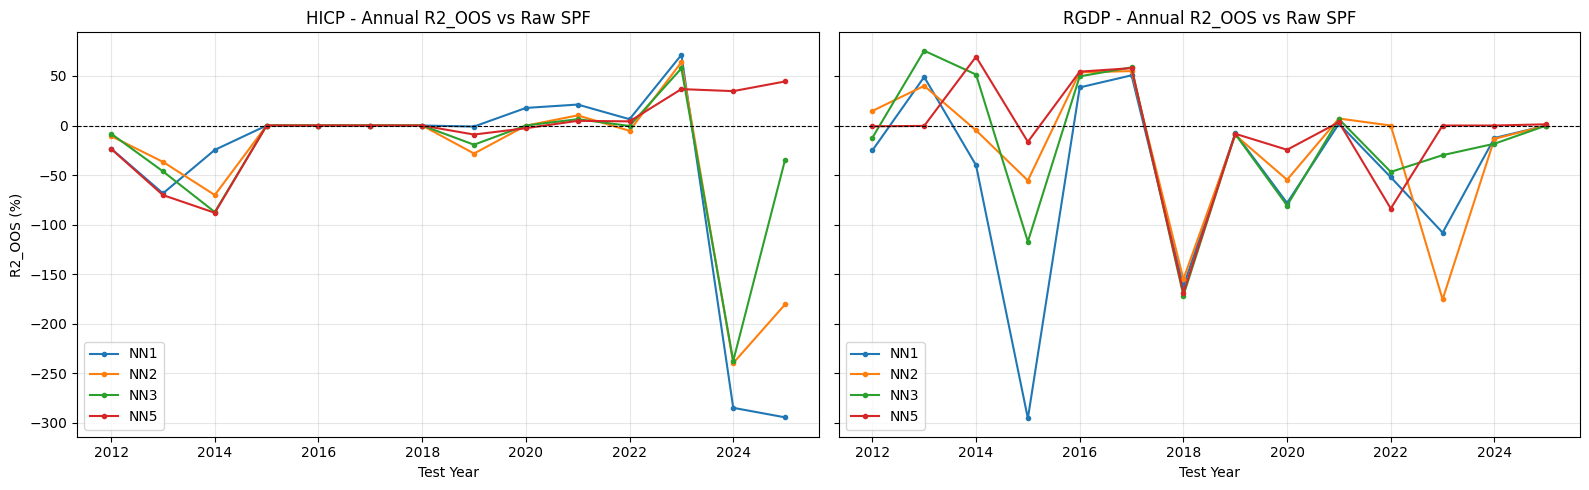

In [13]:
# ====================================================
# Time series plot of annual R2_OOS
# ====================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, target_variable in zip(axes, TARGET_VARIABLES):
    for arch_name in archs_to_run:
        key = f"{target_variable}_{arch_name}"
        if key in annual_r2_df:
            ax.plot(
                annual_r2_df.index,
                annual_r2_df[key],
                marker="o",
                markersize=3,
                label=arch_name,
            )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Test Year")
    ax.set_title(f"{target_variable} - Annual R2_OOS vs Raw SPF")
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_ylabel("R2_OOS (%)")
plt.tight_layout()
plt.show()


---
## Step 14: Variable Importance (SSD)

SSD measures how sensitive the predicted forecast error is to each input
feature. The values are computed on standardized features, so they are best
interpreted as relative importance within this model pipeline.

In [15]:
# ====================================================
# Variable Importance via SSD (using saved NN3 models)
# ====================================================

def compute_ssd(
    model: nn.Module,
    X: torch.Tensor,
    feature_names: list[str],
    batch_size: int = BATCH_SIZE,
) -> pd.Series:
    """Compute Sum of Squared Derivatives for each input feature."""
    ssd_total = torch.zeros(len(feature_names), dtype=torch.float64)
    model = model.to(DEVICE)
    model.eval()

    for start in range(0, X.shape[0], batch_size):
        stop = start + batch_size
        X_batch = X[start:stop].to(DEVICE).clone().detach().requires_grad_(True)
        model.zero_grad(set_to_none=True)
        preds = model(X_batch)
        preds.sum().backward()
        grads = X_batch.grad.detach().cpu()
        ssd_total += (grads ** 2).sum(dim=0).double()

    clear_device_cache()
    return pd.Series(ssd_total.numpy(), index=feature_names)


def compute_saved_model_ssd(
    state_dicts: list[dict[str, torch.Tensor]],
    hidden_sizes: list[int],
    split: dict,
    max_obs: int = SSD_MAX_OBS,
) -> pd.Series:
    """Average SSD across saved final-split ensemble members."""
    X_train, _, _, _, _, _ = get_split_views(split)

    if X_train.shape[0] > max_obs:
        generator = torch.Generator().manual_seed(0)
        idx = torch.randperm(X_train.shape[0], generator=generator)[:max_obs]
        X_ssd = X_train[idx.to(X_train.device)]
    else:
        X_ssd = X_train

    ssd_total = pd.Series(0.0, index=feature_cols)
    input_dim = len(feature_cols)

    for state_dict in state_dicts:
        model = GKXNet(input_dim, hidden_sizes)
        model.load_state_dict(state_dict)
        ssd_total += compute_ssd(model, X_ssd, feature_cols)
        del model
        clear_device_cache()

    ssd_avg = ssd_total / len(state_dicts)
    ssd_pct = (ssd_avg / ssd_avg.sum()) * 100
    return ssd_pct.sort_values(ascending=False)


ssd_results = {}

if ENABLE_SSD:
    for target_variable in TARGET_VARIABLES:
        nn3_result = results.get(target_variable, {}).get("NN3")
        if nn3_result and nn3_result.get("ssd_state_dicts"):
            set_active_variable(target_variable, quiet=True)
            print(f"Computing SSD for {target_variable} NN3...")
            ssd_results[target_variable] = compute_saved_model_ssd(
                nn3_result["ssd_state_dicts"],
                NN_ARCHITECTURES["NN3"],
                nn3_result["ssd_split"],
            )
            print(ssd_results[target_variable].head(20).to_string())
            print()
        else:
            print(f"Skipping SSD for {target_variable}: NN3 saved models are not available.")
else:
    print("Skipping SSD because ENABLE_SSD=False.")

Computing SSD for HICP NN3...
forecast_disagreement_rolling_1y      14.682614
distance_from_consensus_rolling_1y     8.759173
EMPIT_EA                               7.310284
PPIING_EA                              3.273104
EMPPA_EA                               3.247883
PPIDCOG_EA                             3.243483
CCI_EA                                 2.865612
GHIR_EA                                2.764122
EMPRE_EA                               2.744987
LTIRT_EACC                             2.624125
CCONFIX_EA                             2.495625
rolling_1y_forecast                    2.094206
UNEO25_EA                              1.900579
GHSR_EA                                1.743373
UNETOT_EA                              1.561641
HHASS.LLN_EA                           1.438894
GGLB.LLN_EA                            1.437291
M1_EACC                                1.334896
NFCLB_EA                               1.202592
EMPFC_EA                               1.137339

Computing

---
## Step 15: Plot Variable Importance

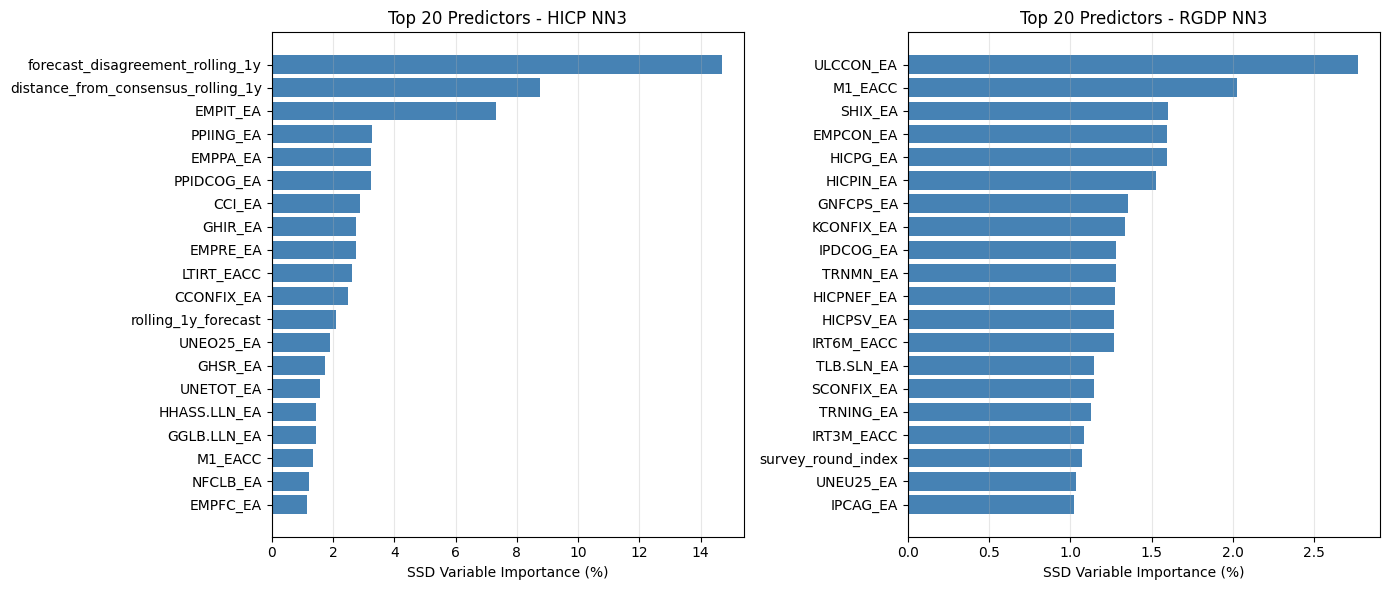

In [16]:
# ====================================================
# Bar chart of top-20 SSD variable importance
# ====================================================

if not ssd_results:
    print("SSD plot skipped because no SSD results are available.")
else:
    top_n = 20
    n_panels = len(ssd_results)
    fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6), squeeze=False)

    for ax, (target_variable, ssd_series) in zip(axes.ravel(), ssd_results.items()):
        top_ssd = ssd_series.head(top_n)
        ax.barh(range(len(top_ssd)), top_ssd.values[::-1], color="steelblue")
        ax.set_yticks(range(len(top_ssd)))
        ax.set_yticklabels(top_ssd.index[::-1])
        ax.set_xlabel("SSD Variable Importance (%)")
        ax.set_title(f"Top {top_n} Predictors - {target_variable} NN3")
        ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## Step 16: Summary Results Table

In [17]:
# ====================================================
# Summary comparison table
# ====================================================

def rmse(values: np.ndarray) -> float:
    return float(np.sqrt(np.mean(values ** 2)))


summary_rows = []
for target_variable, variable_results in results.items():
    for arch_name in archs_to_run:
        res = variable_results[arch_name]
        actual_errors = res["actuals"]
        predicted_errors = res["preds"]
        residual_errors = actual_errors - predicted_errors

        calibration = res.get("calibration", pd.DataFrame())
        mean_alpha = calibration["alpha"].mean() if "alpha" in calibration else np.nan
        mean_clipped_share = (
            calibration["test_prediction_clipped_share"].mean() * 100
            if "test_prediction_clipped_share" in calibration
            else np.nan
        )

        summary_rows.append({
            "Variable": target_variable,
            "Architecture": arch_name,
            "Hidden Layers": str(NN_ARCHITECTURES[arch_name]),
            "R2_zero (%)": f"{r2_oos(actual_errors, predicted_errors) * 100:.4f}",
            "R2_bias (%)": f"{r2_bias(actual_errors, predicted_errors, res['test_years']) * 100:.4f}",
            "Raw SPF RMSE": f"{rmse(actual_errors):.4f}",
            "NN Corrected RMSE": f"{rmse(residual_errors):.4f}",
            "Raw SPF MAE": f"{np.mean(np.abs(actual_errors)):.4f}",
            "NN Corrected MAE": f"{np.mean(np.abs(residual_errors)):.4f}",
            "Mean alpha": f"{mean_alpha:.3f}",
            "Mean clipped (%)": f"{mean_clipped_share:.1f}",
            "N Test Obs": f"{len(actual_errors):,}",
        })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "=" * 100)
print("SEPARATE HICP AND RGDP FORECAST-ERROR CORRECTION SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))



SEPARATE HICP AND RGDP FORECAST-ERROR CORRECTION SUMMARY
Variable Architecture     Hidden Layers R2_zero (%) R2_bias (%) Raw SPF RMSE NN Corrected RMSE Raw SPF MAE NN Corrected MAE Mean alpha Mean clipped (%) N Test Obs
    HICP          NN1              [32]     13.8371     18.2757       2.3535            2.1846      1.3651           1.3712      0.549              1.2      2,441
    HICP          NN2          [32, 16]      2.7635      7.7726       2.3535            2.3208      1.3651           1.4448      0.622              0.9      2,441
    HICP          NN3       [32, 16, 8]      1.4274      6.5053       2.3535            2.3367      1.3651           1.4310      0.589              0.0      2,441
    HICP          NN5 [32, 16, 8, 4, 2]      1.5960      6.6652       2.3535            2.3347      1.3651           1.4059      0.644              0.0      2,441
    RGDP          NN1              [32]    -22.7180    -15.7414       2.4701            2.7363      1.1789           1.4083    

---
## Step 17: Save Predictions to Drive

The saved files include the original SPF forecast, the realized value, the
actual forecast error, the predicted error, and the corrected forecast.

In [ ]:
# ====================================================
# Save OOS predictions for each variable and architecture
# ====================================================

from pathlib import Path
import pandas as pd

if IN_COLAB:
    output_dir = Path("/content/drive/MyDrive/Final Assignment NN Results/nn_results")
else:
    output_dir = Path("Data/nn_results")

output_dir.mkdir(parents=True, exist_ok=True)

meta_cols = [
    "survey_round",
    "survey_year",
    "survey_quarter",
    "variable",
    "fct_source",
    "rolling_1y_target",
    "rolling_1y_forecast",
    "actual_value",
    "forecast_error",
]

for target_variable, variable_results in results.items():
    for arch_name in archs_to_run:
        res = variable_results[arch_name]
        meta = model_data.loc[res["test_indices"], meta_cols].reset_index(drop=True)

        out_df = meta.copy()
        out_df["actual_forecast_error"] = res["actuals"]
        out_df["predicted_error_raw"] = res.get("preds_raw", res["preds"])
        out_df["predicted_error_clipped"] = res.get("preds_clipped", res["preds"])
        out_df["shrinkage_alpha"] = res.get(
            "shrinkage_alpha",
            np.ones(len(out_df), dtype=np.float32),
        )
        out_df["prediction_clip_lower"] = res.get(
            "prediction_clip_lower",
            np.full(len(out_df), np.nan, dtype=np.float32),
        )
        out_df["prediction_clip_upper"] = res.get(
            "prediction_clip_upper",
            np.full(len(out_df), np.nan, dtype=np.float32),
        )
        out_df["predicted_error"] = res["preds"]
        out_df["corrected_forecast"] = (
            out_df["rolling_1y_forecast"] + out_df["predicted_error"]
        )
        out_df["corrected_forecast_error"] = (
            out_df["actual_value"] - out_df["corrected_forecast"]
        )

        out_path = output_dir / f"{target_variable}_{arch_name}_forecast_error_predictions.csv"
        out_df.to_csv(out_path, index=False)
        print(f"Saved {target_variable} {arch_name} predictions to {out_path}")

print("\nDone. All neural network predictions saved.")

---
## Step 18: Plot Actual Values, Average SPF Forecasts, and NN-Corrected Forecasts

This final plot compares the realized macro variable with the average raw SPF
forecast, selected neural-network-corrected forecasts, and an average correction
across all trained NN architectures.

The plot is aggregated by target period and variable, so each point is the
forecaster-average prediction for that target.

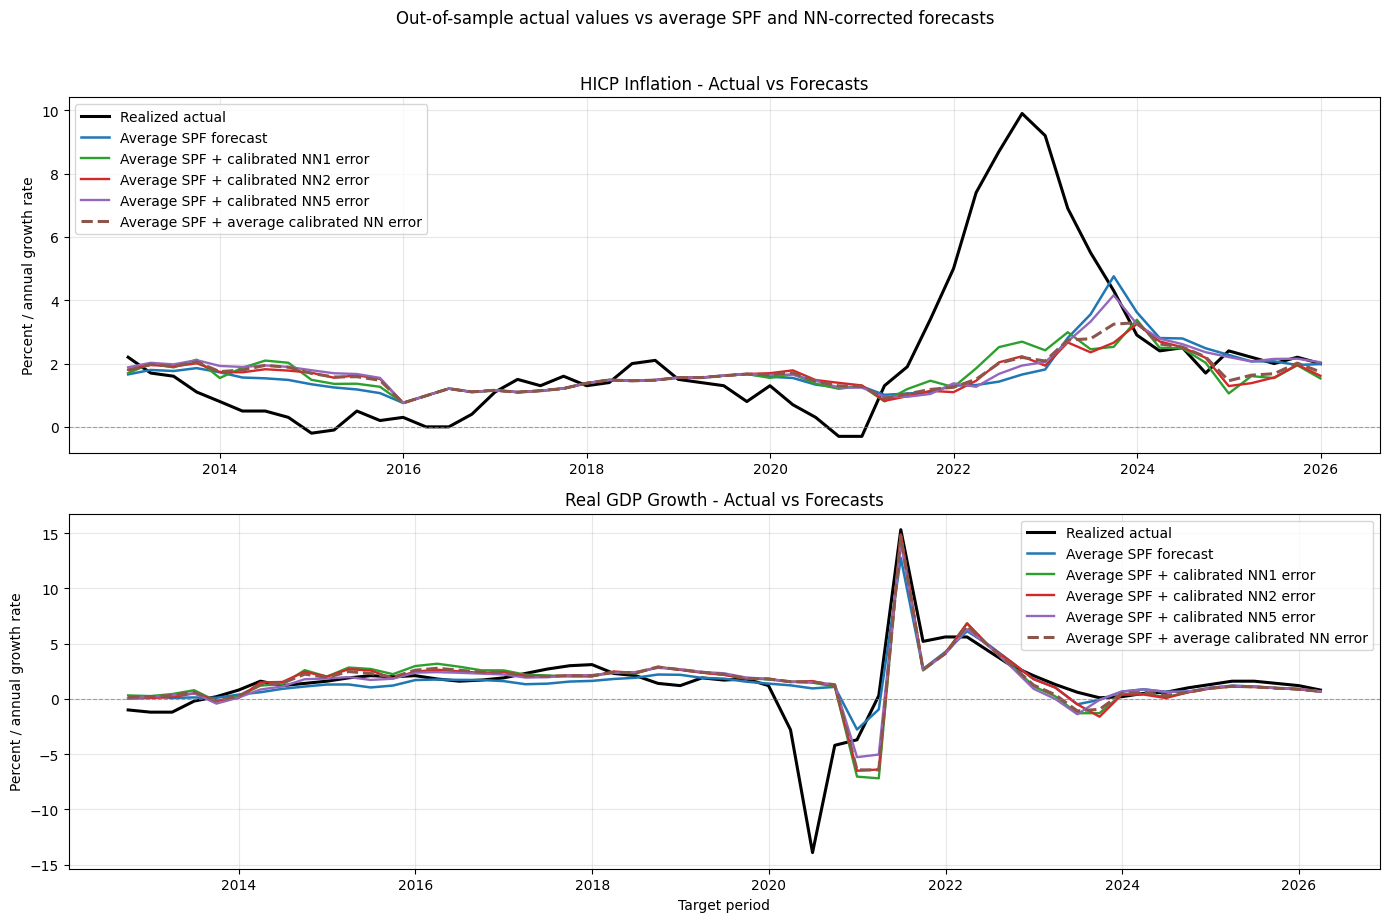

,variable,architecture,rolling_1y_target,plot_date,actual_value,average_spf_forecast,average_nn_corrected_forecast,n_forecasters
412,RGDP,NN_AVG,2021Q2,2021-06-30,15.3,12.749536,14.676690,44
413,RGDP,NN_AVG,2021Q3,2021-09-30,5.2,2.701459,2.635452,52
414,RGDP,NN_AVG,2021Q4,2021-12-31,5.6,4.240408,4.104240,51
415,RGDP,NN_AVG,2022Q1,2022-03-31,5.6,6.126511,6.621578,46
416,RGDP,NN_AVG,2022Q2,2022-06-30,4.3,4.856728,4.750256,46
417,RGDP,NN_AVG,2022Q3,2022-09-30,3.0,3.338983,3.077043,51
418,RGDP,NN_AVG,2022Q4,2022-12-31,2.1,1.792539,1.243691,43
419,RGDP,NN_AVG,2023Q1,2023-03-31,1.3,1.020954,0.373408,43
420,RGDP,NN_AVG,2023Q2,2023-06-30,0.6,-0.490163,-1.092998,45
421,RGDP,NN_AVG,2023Q3,2023-09-30,0.1,-0.083068,-0.942904,46


In [20]:
# ====================================================
# Actual vs average SPF vs average NN-corrected forecasts
# ====================================================

# Plot the main calibrated architectures together. The individual list is
# filtered to the architectures that were actually trained in this run.
PLOT_ARCHES = [arch for arch in ["NN1", "NN2", "NN5"] if arch in archs_to_run]
if not PLOT_ARCHES:
    PLOT_ARCHES = [archs_to_run[0]]

AVERAGE_ARCH_NAME = "NN_AVG"

plot_frames = []
plot_meta_cols = [
    "survey_round",
    "survey_year",
    "survey_quarter",
    "variable",
    "fct_source",
    "rolling_1y_target",
    "target_date",
    "rolling_1y_forecast",
    "actual_value",
]
plot_meta_cols = [col for col in plot_meta_cols if col in model_data.columns]


def build_prediction_frame_from_series(
    target_variable: str,
    architecture: str,
    prediction_series: pd.Series,
) -> pd.DataFrame:
    """Build one plotting frame from indexed predicted forecast errors."""
    meta = model_data.loc[prediction_series.index, plot_meta_cols].reset_index(drop=True)
    meta["architecture"] = architecture
    meta["predicted_error"] = prediction_series.to_numpy(dtype=float)
    meta["nn_corrected_forecast"] = (
        meta["rolling_1y_forecast"] + meta["predicted_error"]
    )
    return meta


for target_variable in TARGET_VARIABLES:
    available_arches = [
        arch for arch in archs_to_run
        if target_variable in results and arch in results[target_variable]
    ]

    for arch_name in PLOT_ARCHES:
        if arch_name not in available_arches:
            print(f"Skipping {target_variable}: {arch_name} results are not available.")
            continue

        res = results[target_variable][arch_name]
        pred_series = pd.Series(res["preds"], index=res["test_indices"], name=arch_name)
        plot_frames.append(
            build_prediction_frame_from_series(target_variable, arch_name, pred_series)
        )

    # Average the calibrated predictions from all trained architectures.
    if len(available_arches) >= 2:
        aligned_predictions = pd.concat(
            [
                pd.Series(
                    results[target_variable][arch]["preds"],
                    index=results[target_variable][arch]["test_indices"],
                    name=arch,
                )
                for arch in available_arches
            ],
            axis=1,
            join="inner",
        ).sort_index()

        avg_prediction_series = aligned_predictions.mean(axis=1).rename(AVERAGE_ARCH_NAME)
        plot_frames.append(
            build_prediction_frame_from_series(
                target_variable,
                AVERAGE_ARCH_NAME,
                avg_prediction_series,
            )
        )
    else:
        print(f"Skipping {target_variable}: need at least two architectures for {AVERAGE_ARCH_NAME}.")

if not plot_frames:
    raise ValueError("No prediction results available for the final actual-vs-forecast plot.")

prediction_plot_data = pd.concat(plot_frames, ignore_index=True)

if "target_date" in prediction_plot_data.columns:
    prediction_plot_data["plot_date"] = pd.to_datetime(
        prediction_plot_data["target_date"],
        errors="coerce",
    )
else:
    prediction_plot_data["plot_date"] = pd.to_datetime(
        prediction_plot_data["survey_year"].astype(str)
        + "Q"
        + prediction_plot_data["survey_quarter"].astype(str)
    )

average_forecasts = (
    prediction_plot_data
    .groupby(["variable", "architecture", "rolling_1y_target", "plot_date"], as_index=False)
    .agg(
        actual_value=("actual_value", "mean"),
        average_spf_forecast=("rolling_1y_forecast", "mean"),
        average_nn_corrected_forecast=("nn_corrected_forecast", "mean"),
        n_forecasters=("fct_source", "nunique"),
    )
    .sort_values(["variable", "architecture", "plot_date"])
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
variable_titles = {
    "HICP": "HICP Inflation",
    "RGDP": "Real GDP Growth",
}
arch_colors = {
    "NN1": "tab:green",
    "NN2": "tab:red",
    "NN3": "tab:orange",
    "NN5": "tab:purple",
    AVERAGE_ARCH_NAME: "tab:brown",
}
arch_linestyles = {
    "NN1": "-",
    "NN2": "-",
    "NN3": "-",
    "NN5": "-",
    AVERAGE_ARCH_NAME: "--",
}

for ax, target_variable in zip(axes, TARGET_VARIABLES):
    variable_df = average_forecasts.loc[
        average_forecasts["variable"] == target_variable
    ].copy()

    if variable_df.empty:
        ax.set_visible(False)
        continue

    base_df = variable_df.loc[variable_df["architecture"] == variable_df["architecture"].iloc[0]].copy()

    ax.plot(
        base_df["plot_date"],
        base_df["actual_value"],
        color="black",
        linewidth=2.2,
        label="Realized actual",
    )
    ax.plot(
        base_df["plot_date"],
        base_df["average_spf_forecast"],
        color="tab:blue",
        linewidth=1.8,
        label="Average SPF forecast",
    )

    line_arches = [arch for arch in [*PLOT_ARCHES, AVERAGE_ARCH_NAME] if arch in variable_df["architecture"].unique()]
    for arch_name in line_arches:
        series_df = variable_df.loc[variable_df["architecture"] == arch_name].copy()
        if series_df.empty:
            continue

        label = (
            "Average SPF + average calibrated NN error"
            if arch_name == AVERAGE_ARCH_NAME
            else f"Average SPF + calibrated {arch_name} error"
        )
        linewidth = 2.2 if arch_name == AVERAGE_ARCH_NAME else 1.7

        ax.plot(
            series_df["plot_date"],
            series_df["average_nn_corrected_forecast"],
            linewidth=linewidth,
            linestyle=arch_linestyles.get(arch_name, "-"),
            color=arch_colors.get(arch_name),
            label=label,
        )

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.set_title(f"{variable_titles.get(target_variable, target_variable)} - Actual vs Forecasts")
    ax.set_ylabel("Percent / annual growth rate")
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Target period")
fig.suptitle(
    "Out-of-sample actual values vs average SPF and NN-corrected forecasts",
    y=1.02,
)
plt.tight_layout()
plt.show()

display(average_forecasts.tail(20))

---
## Step 19: Forecast Comparison Table and Statistical Test

This table directly asks whether adding the neural network's predicted error
improves the SPF forecast. It includes each trained architecture and an
`NN_AVG` row that averages the calibrated predictions across all trained NN
architectures.

The comparison is done at the target-period average level, not at the
individual-forecaster row level. This matters because many forecasters predict
the same target period, so those rows are not independent observations for a
statistical test.

The test is a Diebold-Mariano-style loss-difference test with Newey-West
standard errors:

```text
loss_difference_t = raw_SPF_loss_t - NN_corrected_loss_t
```

A positive mean loss difference means the NN-corrected forecast has lower loss.
The reported p-values are two-sided tests of equal predictive accuracy.

In [21]:
# ====================================================
# Forecast comparison table with DM-style HAC tests
# ====================================================

DM_MAX_LAG = 4
AVERAGE_ARCH_NAME = "NN_AVG"


def metric_rmse(values: np.ndarray) -> float:
    """RMSE helper local to the final comparison table."""
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values ** 2)))


def newey_west_mean_test(loss_diff: np.ndarray, max_lag: int = DM_MAX_LAG) -> dict:
    """Test whether the mean loss difference differs from zero.

    Positive loss_diff means the NN-corrected forecast has smaller loss than
    the raw SPF forecast. Newey-West standard errors allow for serial
    correlation in target-period losses.
    """
    d = np.asarray(loss_diff, dtype=float)
    d = d[np.isfinite(d)]
    n = len(d)

    if n < 3:
        return {
            "n": n,
            "mean_diff": np.nan,
            "stat": np.nan,
            "p_two_sided": np.nan,
        }

    mean_diff = float(np.mean(d))
    demeaned = d - mean_diff
    lag = min(max_lag, n - 1)

    long_run_var = float(np.dot(demeaned, demeaned) / n)
    for k in range(1, lag + 1):
        gamma_k = float(np.dot(demeaned[k:], demeaned[:-k]) / n)
        weight = 1.0 - k / (lag + 1)
        long_run_var += 2.0 * weight * gamma_k

    long_run_var = max(long_run_var, 0.0)
    se_mean = float(np.sqrt(long_run_var / n))

    if se_mean == 0:
        stat = np.inf if mean_diff > 0 else -np.inf if mean_diff < 0 else 0.0
        p_two_sided = 0.0 if mean_diff != 0 else 1.0
    else:
        stat = mean_diff / se_mean
        p_two_sided = 2.0 * stats.norm.sf(abs(stat))

    return {
        "n": n,
        "mean_diff": mean_diff,
        "stat": float(stat),
        "p_two_sided": float(p_two_sided),
    }


def comparison_verdict(improvement_pct: float, p_value: float) -> str:
    """Human-readable verdict based on RMSE improvement and squared-loss test."""
    if np.isnan(improvement_pct) or np.isnan(p_value):
        return "Not enough data"

    direction = "better" if improvement_pct > 0 else "worse" if improvement_pct < 0 else "same"
    if direction == "same":
        return "Same RMSE"

    suffix = "statistically significant" if p_value < 0.05 else "not statistically significant"
    return f"NN {direction} ({suffix})"


def get_prediction_series(target_variable: str, arch_name: str) -> pd.Series:
    """Return indexed calibrated predictions for one architecture or NN_AVG."""
    if arch_name == AVERAGE_ARCH_NAME:
        available_arches = [
            arch for arch in archs_to_run
            if target_variable in results and arch in results[target_variable]
        ]
        if len(available_arches) < 2:
            raise ValueError(f"Need at least two architectures to build {AVERAGE_ARCH_NAME}.")

        aligned_predictions = pd.concat(
            [
                pd.Series(
                    results[target_variable][arch]["preds"],
                    index=results[target_variable][arch]["test_indices"],
                    name=arch,
                )
                for arch in available_arches
            ],
            axis=1,
            join="inner",
        ).sort_index()
        return aligned_predictions.mean(axis=1).rename(AVERAGE_ARCH_NAME)

    res = results[target_variable][arch_name]
    return pd.Series(res["preds"], index=res["test_indices"], name=arch_name)


def build_architecture_forecast_frame(target_variable: str, arch_name: str) -> pd.DataFrame:
    """Build target-period average raw and NN-corrected forecasts."""
    prediction_series = get_prediction_series(target_variable, arch_name)

    needed_cols = [
        "survey_round",
        "survey_year",
        "survey_quarter",
        "variable",
        "fct_source",
        "rolling_1y_target",
        "target_date",
        "rolling_1y_forecast",
        "actual_value",
    ]
    needed_cols = [col for col in needed_cols if col in model_data.columns]

    meta = model_data.loc[prediction_series.index, needed_cols].reset_index(drop=True)
    meta["predicted_error"] = prediction_series.to_numpy(dtype=float)
    meta["nn_corrected_forecast"] = meta["rolling_1y_forecast"] + meta["predicted_error"]

    if "target_date" in meta.columns:
        meta["plot_date"] = pd.to_datetime(meta["target_date"], errors="coerce")
    else:
        meta["plot_date"] = pd.to_datetime(
            meta["survey_year"].astype(str) + "Q" + meta["survey_quarter"].astype(str)
        )

    grouped = (
        meta
        .groupby(["variable", "rolling_1y_target", "plot_date"], as_index=False)
        .agg(
            actual_value=("actual_value", "mean"),
            average_spf_forecast=("rolling_1y_forecast", "mean"),
            average_nn_corrected_forecast=("nn_corrected_forecast", "mean"),
            n_forecasters=("fct_source", "nunique"),
        )
        .sort_values("plot_date")
    )

    grouped["raw_error"] = grouped["actual_value"] - grouped["average_spf_forecast"]
    grouped["nn_corrected_error"] = (
        grouped["actual_value"] - grouped["average_nn_corrected_forecast"]
    )
    return grouped


comparison_rows = []
comparison_frames = {}

for target_variable in TARGET_VARIABLES:
    comparison_frames[target_variable] = {}

    available_arches = [
        arch for arch in archs_to_run
        if target_variable in results and arch in results[target_variable]
    ]
    comparison_arches = available_arches.copy()
    if len(available_arches) >= 2:
        comparison_arches.append(AVERAGE_ARCH_NAME)

    for arch_name in comparison_arches:
        forecast_frame = build_architecture_forecast_frame(target_variable, arch_name)
        comparison_frames[target_variable][arch_name] = forecast_frame

        raw_error = forecast_frame["raw_error"].to_numpy()
        corrected_error = forecast_frame["nn_corrected_error"].to_numpy()

        raw_rmse = metric_rmse(raw_error)
        corrected_rmse = metric_rmse(corrected_error)
        raw_mae = float(np.mean(np.abs(raw_error)))
        corrected_mae = float(np.mean(np.abs(corrected_error)))

        rmse_improvement_pct = 100.0 * (raw_rmse - corrected_rmse) / raw_rmse
        mae_improvement_pct = 100.0 * (raw_mae - corrected_mae) / raw_mae

        squared_loss_diff = raw_error ** 2 - corrected_error ** 2
        absolute_loss_diff = np.abs(raw_error) - np.abs(corrected_error)

        squared_test = newey_west_mean_test(squared_loss_diff)
        absolute_test = newey_west_mean_test(absolute_loss_diff)

        comparison_rows.append({
            "Variable": target_variable,
            "Architecture": arch_name,
            "N target periods": int(len(forecast_frame)),
            "Raw SPF RMSE": raw_rmse,
            "NN Corrected RMSE": corrected_rmse,
            "RMSE improvement (%)": rmse_improvement_pct,
            "Raw SPF MAE": raw_mae,
            "NN Corrected MAE": corrected_mae,
            "MAE improvement (%)": mae_improvement_pct,
            "Mean squared-loss diff": squared_test["mean_diff"],
            "DM stat squared loss": squared_test["stat"],
            "DM p squared loss": squared_test["p_two_sided"],
            "Mean absolute-loss diff": absolute_test["mean_diff"],
            "DM stat absolute loss": absolute_test["stat"],
            "DM p absolute loss": absolute_test["p_two_sided"],
            "RMSE verdict": comparison_verdict(
                rmse_improvement_pct,
                squared_test["p_two_sided"],
            ),
        })

forecast_comparison_df = pd.DataFrame(comparison_rows)

display_cols = [
    "Variable",
    "Architecture",
    "N target periods",
    "Raw SPF RMSE",
    "NN Corrected RMSE",
    "RMSE improvement (%)",
    "Raw SPF MAE",
    "NN Corrected MAE",
    "MAE improvement (%)",
    "DM stat squared loss",
    "DM p squared loss",
    "DM p absolute loss",
    "RMSE verdict",
]

formatted_comparison = forecast_comparison_df[display_cols].copy()
numeric_format_cols = [
    "Raw SPF RMSE",
    "NN Corrected RMSE",
    "RMSE improvement (%)",
    "Raw SPF MAE",
    "NN Corrected MAE",
    "MAE improvement (%)",
    "DM stat squared loss",
    "DM p squared loss",
    "DM p absolute loss",
]
for col in numeric_format_cols:
    formatted_comparison[col] = formatted_comparison[col].map(lambda x: f"{x:.4f}")

print("Forecast comparison using target-period average forecasts")
print("Positive improvement means the NN-corrected forecast has lower error.")
print("DM p-values are two-sided; p < 0.05 is treated as statistically significant.")
display(formatted_comparison)


Forecast comparison using target-period average forecasts
Positive improvement means the NN-corrected forecast has lower error.
DM p-values are two-sided; p < 0.05 is treated as statistically significant.


,Variable,Architecture,N target periods,Raw SPF RMSE,NN Corrected RMSE,RMSE improvement (%),Raw SPF MAE,NN Corrected MAE,MAE improvement (%),DM stat squared loss,DM p squared loss,DM p absolute loss,RMSE verdict
0,HICP,NN1,53,2.2856,2.1477,6.0337,1.2821,1.3294,-3.6824,0.8379,0.4021,0.5119,NN better (not statistically significant)
1,HICP,NN2,53,2.2856,2.2823,0.1443,1.2821,1.3990,-9.1137,0.0439,0.9650,0.0207,NN better (not statistically significant)
2,HICP,NN3,53,2.2856,2.2911,-0.2414,1.2821,1.3719,-7.0024,-0.1130,0.9100,0.0551,NN worse (not statistically significant)
3,HICP,NN5,53,2.2856,2.2828,0.1219,1.2821,1.3328,-3.9532,0.0598,0.9523,0.2874,NN better (not statistically significant)
4,HICP,NN_AVG,53,2.2856,2.2454,1.7620,1.2821,1.3561,-5.7653,0.4941,0.6213,0.1106,NN better (not statistically significant)
5,RGDP,NN1,55,2.3456,2.6793,-14.2259,1.0429,1.3427,-28.7486,-1.4519,0.1465,0.0261,NN worse (not statistically significant)
6,RGDP,NN2,55,2.3456,2.6107,-11.2993,1.0429,1.2321,-18.1446,-1.3209,0.1865,0.1014,NN worse (not statistically significant)
7,RGDP,NN3,55,2.3456,2.6611,-13.4475,1.0429,1.2553,-20.3681,-1.3226,0.1860,0.1326,NN worse (not statistically significant)
8,RGDP,NN5,55,2.3456,2.5352,-8.0835,1.0429,1.1859,-13.7089,-1.3889,0.1649,0.1568,NN worse (not statistically significant)
9,RGDP,NN_AVG,55,2.3456,2.6114,-11.3321,1.0429,1.2445,-19.3320,-1.3447,0.1787,0.0973,NN worse (not statistically significant)


---
## Summary

This notebook trains feed-forward neural networks to predict SPF rolling
one-year-ahead forecast errors.

| Step | Description |
|---|---|
| 1 | Load `final_model_dataset.csv` from Google Drive |
| 2 | Select the forecast-error target and numeric features |
| 3 | Build chronological expanding-window splits |
| 4 | Define MLP architectures with dropout |
| 5 | Train separate HICP and RGDP models |
| 6 | Evaluate corrections against both the raw SPF forecast and a rolling historical bias correction |
| 7 | Save out-of-sample corrected forecasts |
| 8 | Calibrate NN corrections with train-window clipping and validation OLS shrinkage |
| 9 | Plot actual values against average SPF and NN-corrected forecasts |
| 10 | Compare raw SPF vs NN-corrected forecasts, including the all-NN average, with statistical tests |

The first clean run drops the other SPF horizon forecasts and keeps only
`rolling_1y_forecast` as the forecast being corrected. The two reported
R2 metrics answer different questions: `R2_zero` tests whether the network
improves on doing no correction, while `R2_bias` tests whether it improves
on the simple rule of correcting by the historical mean forecast error.
